### Predicting Anaemia from Image Pixels and Hemoglobin Levels
#### Predictive modelling

In [83]:
#Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import joblib

#### Data Cleaning

In [84]:
df = pd.read_csv("anaemiadata.csv")
print(df.head()) #Displaying the first few rows of the dataset.

print("Shape:",df.shape) #Summary of the dataset's structure and contents.
print("Columns:",df.columns)
#print("Info:",df.info())
df.describe()


#Data Cleaning

print("Number of duplicate rows before cleaning:", df.duplicated().sum()) # Checking for Duplicates
df = df.drop_duplicates() #Removing any duplicate rows.

# Handling Missing Values
print("\nNumber of missing values in each column:")
print( df.isnull().sum())

#Dropping rows with missing values
df = df.dropna()

print("\n Types",df.dtypes)




   Number Sex  %Red Pixel  %Green pixel  %Blue pixel    Hb Anaemic
0       1   M     43.2555       30.8421      25.9025   6.3     Yes
1       2   F     45.6033       28.1900      26.2067  13.5      No
2       3   F     45.0107       28.9677      26.0215  11.7      No
3       4   F     44.5398       28.9899      26.4703  13.5      No
4       5   M     43.2870       30.6972      26.0158  12.4      No
Shape: (104, 7)
Columns: Index(['Number', 'Sex', '%Red Pixel', '%Green pixel', '%Blue pixel', 'Hb',
       'Anaemic'],
      dtype='object')
Number of duplicate rows before cleaning: 0

Number of missing values in each column:
Number          0
Sex             0
%Red Pixel      0
%Green pixel    0
%Blue pixel     0
Hb              0
Anaemic         0
dtype: int64

 Types Number            int64
Sex              object
%Red Pixel      float64
%Green pixel    float64
%Blue pixel     float64
Hb              float64
Anaemic          object
dtype: object


#### Converting 'Yes'/'No' to numerical values from the 'Anaemic' column, where Yes - 1, No - 0

In [85]:

# Replace 'column_name' with the actual column name containing 'yes'/'no' values
df['Anaemic'] = df['Anaemic'].map({'Yes': 1, 'No': 0})

# Checking the types of the columns after conversion
print("\nTypes after conversion:\n", df.dtypes)

# Displaying the first few rows of the updated dataset
print(df.head())


Types after conversion:
 Number            int64
Sex              object
%Red Pixel      float64
%Green pixel    float64
%Blue pixel     float64
Hb              float64
Anaemic           int64
dtype: object
   Number Sex  %Red Pixel  %Green pixel  %Blue pixel    Hb  Anaemic
0       1   M     43.2555       30.8421      25.9025   6.3        1
1       2   F     45.6033       28.1900      26.2067  13.5        0
2       3   F     45.0107       28.9677      26.0215  11.7        0
3       4   F     44.5398       28.9899      26.4703  13.5        0
4       5   M     43.2870       30.6972      26.0158  12.4        0


#### Converting 'M'/'F' to numerical values from the 'Sev' column, where M - 1, F - 0

In [86]:
# Replace 'column_name' with the actual column name containing 'yes'/'no' values
df['Sex'] = df['Sex'].map({'M': 1, 'F': 0})

# Checking the types of the columns after conversion
print("\nTypes after conversion:\n", df.dtypes)

# Displaying the first few rows of the updated dataset
print(df.head())


Types after conversion:
 Number            int64
Sex               int64
%Red Pixel      float64
%Green pixel    float64
%Blue pixel     float64
Hb              float64
Anaemic           int64
dtype: object
   Number  Sex  %Red Pixel  %Green pixel  %Blue pixel    Hb  Anaemic
0       1    1     43.2555       30.8421      25.9025   6.3        1
1       2    0     45.6033       28.1900      26.2067  13.5        0
2       3    0     45.0107       28.9677      26.0215  11.7        0
3       4    0     44.5398       28.9899      26.4703  13.5        0
4       5    1     43.2870       30.6972      26.0158  12.4        0


### Predictive modelling
- Splitting Data
- Feature Scaling
- Choosing a Model
- Training the Model
- Evaluating the Model
- Hyperparameter Tuning
- Cross-Validation
- Deployment

In [87]:
#Defining features and target variable
features = ['Sex', '%Red Pixel', '%Green pixel', '%Blue pixel', 'Hb']
target = 'Anaemic'

X = df[features]  # Features
y = df[target]    # Target variable


print("Shape of X:", X.shape)  #number of samples, number of features
print("Shape of y:", y.shape)  #number of samples



Shape of X: (104, 5)
Shape of y: (104,)


In [88]:
#Splitting the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [89]:
# #Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [90]:
# #Choosing a Model (Random Forest)
# model = RandomForestClassifier(random_state=42)

# # Training the Model
# model.fit(X_train_scaled, y_train)


# Choosing a Model (Logistic Regression)
model = LogisticRegression(random_state=42)

# Training the Model
model.fit(X_train_scaled, y_train)


LogisticRegression(random_state=42)

In [91]:
#Model Evaluation
y_pred = model.predict(X_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 1.0
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         5

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21

Confusion Matrix:
 [[16  0]
 [ 0  5]]


In [92]:
# #Hyperparameter tuning
# param_grid = {
#     'n_estimators': [100, 200, 300],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4]
# }

# grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)
# grid_search.fit(X_train_scaled, y_train)

# print("Best Parameters:", grid_search.best_params_)

In [93]:
# Cross-Validation
# cross_val_scores = cross_val_score(grid_search.best_estimator_, X_train_scaled, y_train, cv=5)
# print("Cross-Validation Scores:", cross_val_scores)
# print("Mean Cross-Validation Score:", cross_val_scores.mean())

cross_val_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
print("Cross-Validation Scores:", cross_val_scores)
print("Mean Cross-Validation Score:", cross_val_scores.mean())

Cross-Validation Scores: [0.94117647 1.         1.         0.9375     0.875     ]
Mean Cross-Validation Score: 0.9507352941176471


In [94]:
# # Final Model Training with Best Parameters
# final_model = grid_search.best_estimator_
# final_model.fit(X_train_scaled, y_train)

# # Final Evaluation on Test Data
# final_y_pred = final_model.predict(X_test_scaled)
# print("Final Model Accuracy:", accuracy_score(y_test, final_y_pred))
# print("Final Model Classification Report:\n", classification_report(y_test, final_y_pred))
# print("Final Model Confusion Matrix:\n", confusion_matrix(y_test, final_y_pred))

# Final Model Training with Best Parameters
model.fit(X_train_scaled, y_train)

# Final Evaluation on Test Data
final_y_pred = model.predict(X_test_scaled)
print("Final Model Accuracy:", accuracy_score(y_test, final_y_pred))
print("Final Model Classification Report:\n", classification_report(y_test, final_y_pred))
print("Final Model Confusion Matrix:\n", confusion_matrix(y_test, final_y_pred))


Final Model Accuracy: 1.0
Final Model Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        16
           1       1.00      1.00      1.00         5

    accuracy                           1.00        21
   macro avg       1.00      1.00      1.00        21
weighted avg       1.00      1.00      1.00        21

Final Model Confusion Matrix:
 [[16  0]
 [ 0  5]]


In [95]:
# Saving the model and scaler for future use
# joblib.dump(final_model, 'anaemia_randomforest_model.pkl')
# joblib.dump(scaler, 'scaler.pkl')

# Save the model and scaler for future use
joblib.dump(model, 'anaemia_logistic_regression_model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

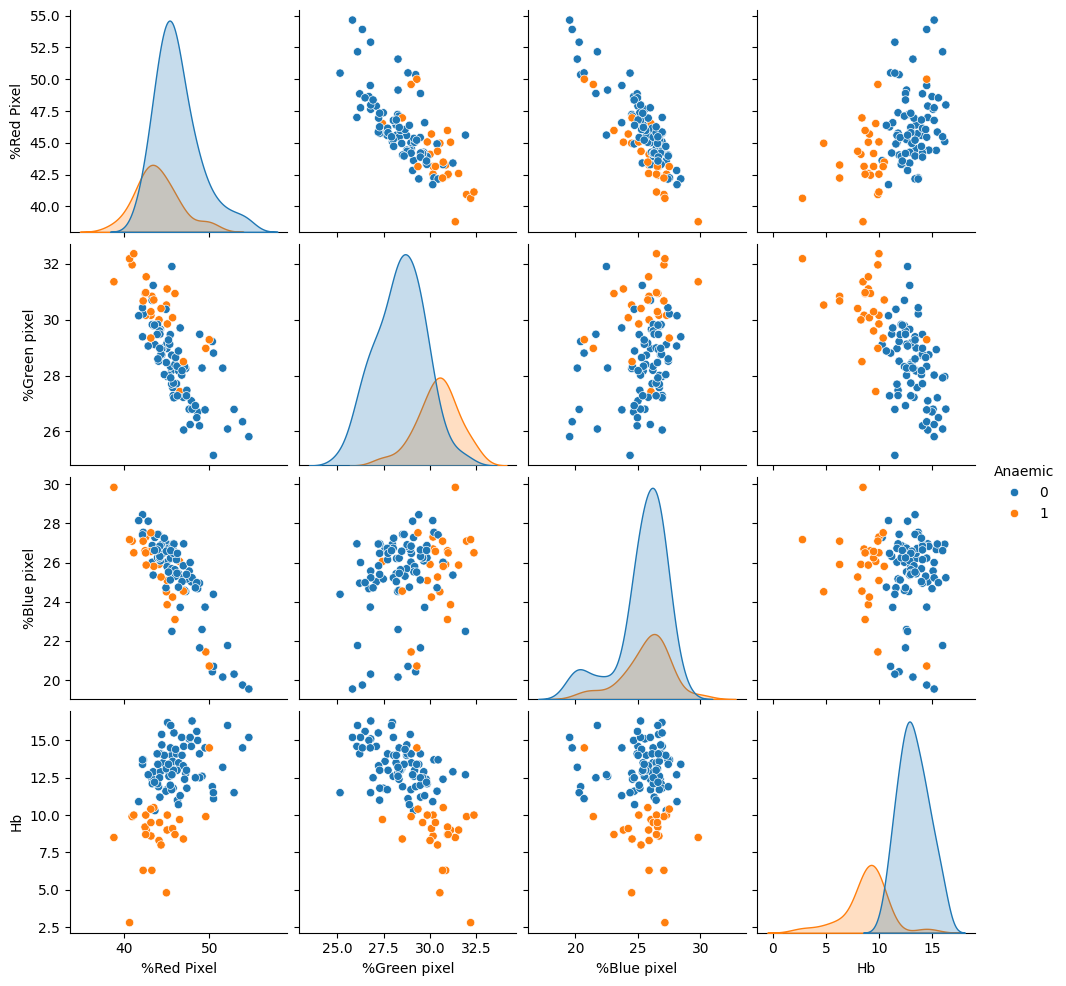

In [96]:
sns.pairplot(df, hue='Anaemic', vars=['%Red Pixel', '%Green pixel', '%Blue pixel', 'Hb'])
plt.show()


In [97]:
correlation_matrix = df.corr()
print(correlation_matrix['Anaemic'].sort_values(ascending=False))


Anaemic         1.000000
%Green pixel    0.566447
%Blue pixel     0.057844
Number          0.053997
Sex            -0.211307
%Red Pixel     -0.353376
Hb             -0.766506
Name: Anaemic, dtype: float64
